## Loading dataset

#### Import necessary libraries and download the dataset.

In [40]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV, StratifiedKFold


path = kagglehub.dataset_download("vicsuperman/prediction-of-music-genre")
print("Path to dataset files:", path)

# List files in the downloaded dataset
files = os.listdir(path)
print("Dataset files:", files)

df = pd.read_csv(os.path.join(path, "music_genre.csv"))
df.head()

Path to dataset files: /Users/scottwu/.cache/kagglehub/datasets/vicsuperman/prediction-of-music-genre/versions/1
Dataset files: ['music_genre.csv']


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


## Data Cleaning and Encoding

#### Cleaning the below:
- Cleanup the rows with "?", -1, and then convert the columns to float type.
- Remove duplicated tracks.
- Remove outliers in 'duration_ms' with the lonest 1% of the data.
- Drop unrelated columns.

In [41]:
df["tempo"] = df["tempo"].replace("?", np.nan)
df = df.dropna(subset=["tempo"])
df["tempo"] = df["tempo"].astype(float)

df["key"] = df["key"].replace("?", np.nan)
df = df.dropna(subset=["key"])

df["duration_ms"] = df["duration_ms"].replace(-1.0, np.nan)
df = df.dropna(subset=["duration_ms"])
df["duration_ms"] = df["duration_ms"].astype(float)

print(f"Number of rows before dropping duplicates: {len(df)}")
df = df.drop_duplicates(subset=["artist_name", "track_name"])
print(f"Number of rows after dropping duplicates: {len(df)}")

df = df.drop(columns=["artist_name", "track_name", "instance_id", "obtained_date"])

Number of rows before dropping duplicates: 40560
Number of rows after dropping duplicates: 37967


#### Data encoding and feature combinition
- 'mode' is the target column but it is not numerical. `LabelEncoder` sorts labels alphabetically, so it maps Major = 0, Minor = 1.
- Musical mode is highly related to the emotions, it is helpful for predictions to combine emotion-related variables to create new variables.
- 'key' in musical are ordered in sequence and has a cyclical nature, therefore, they can be encoded cyclically to represent this nature.

In [42]:
label_encoder = LabelEncoder()
df["mode"] = label_encoder.fit_transform(df["mode"])

df["energy_danceability"] = df["energy"] * df["danceability"]
df["valence_danceability"] = df["valence"] * df["danceability"]
df["energy_valence"] = df["energy"] * df["valence"]

df["key"] = label_encoder.fit_transform(df["key"])
df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12)
df = df.drop(columns=["key"])

# Ensure a continuous index after row filtering so later assignments align by row position.
df = df.reset_index(drop=True)
df.head()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo,valence,music_genre,energy_danceability,valence_danceability,energy_valence,key_sin,key_cos
0,31.0,0.01270,0.622,218293.0,0.890,0.950000,0.124,-7.043,1,0.0300,115.002,0.531,Electronic,0.553580,0.330282,0.472590,0.500000,-8.660254e-01
1,28.0,0.00306,0.620,215613.0,0.755,0.011800,0.534,-4.617,0,0.0345,127.994,0.333,Electronic,0.468100,0.206460,0.251415,-0.500000,8.660254e-01
2,34.0,0.02540,0.774,166875.0,0.700,0.002530,0.157,-4.498,0,0.2390,128.014,0.270,Electronic,0.541800,0.208980,0.189000,0.866025,-5.000000e-01
3,32.0,0.00465,0.638,222369.0,0.587,0.909000,0.157,-6.266,0,0.0413,145.036,0.323,Electronic,0.374506,0.206074,0.189601,-1.000000,-1.836970e-16
4,46.0,0.02890,0.572,214408.0,0.803,0.000008,0.106,-4.294,0,0.3510,149.995,0.230,Electronic,0.459316,0.131560,0.184690,0.866025,5.000000e-01


## Data Visualisation

#### Class distribution: Major vs Minor

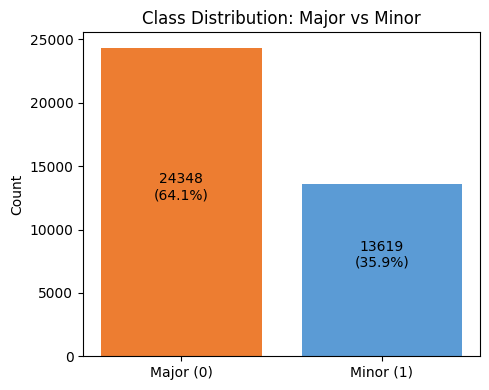

In [43]:
# LabelEncoder maps alphabetically: Major=0, Minor=1
mode_counts = df["mode"].value_counts().sort_index()
labels = ["Major (0)", "Minor (1)"]
colors = ["#ED7D31", "#5B9BD5"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, mode_counts.values, color=colors)
ax.set_title("Class Distribution: Major vs Minor")
ax.set_ylabel("Count")
for bar, count in zip(bars, mode_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_center()[1],
        f"{count}\n({count / len(df) * 100:.1f}%)",
        ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

#### Box plots of each continuous feature grouped by mode

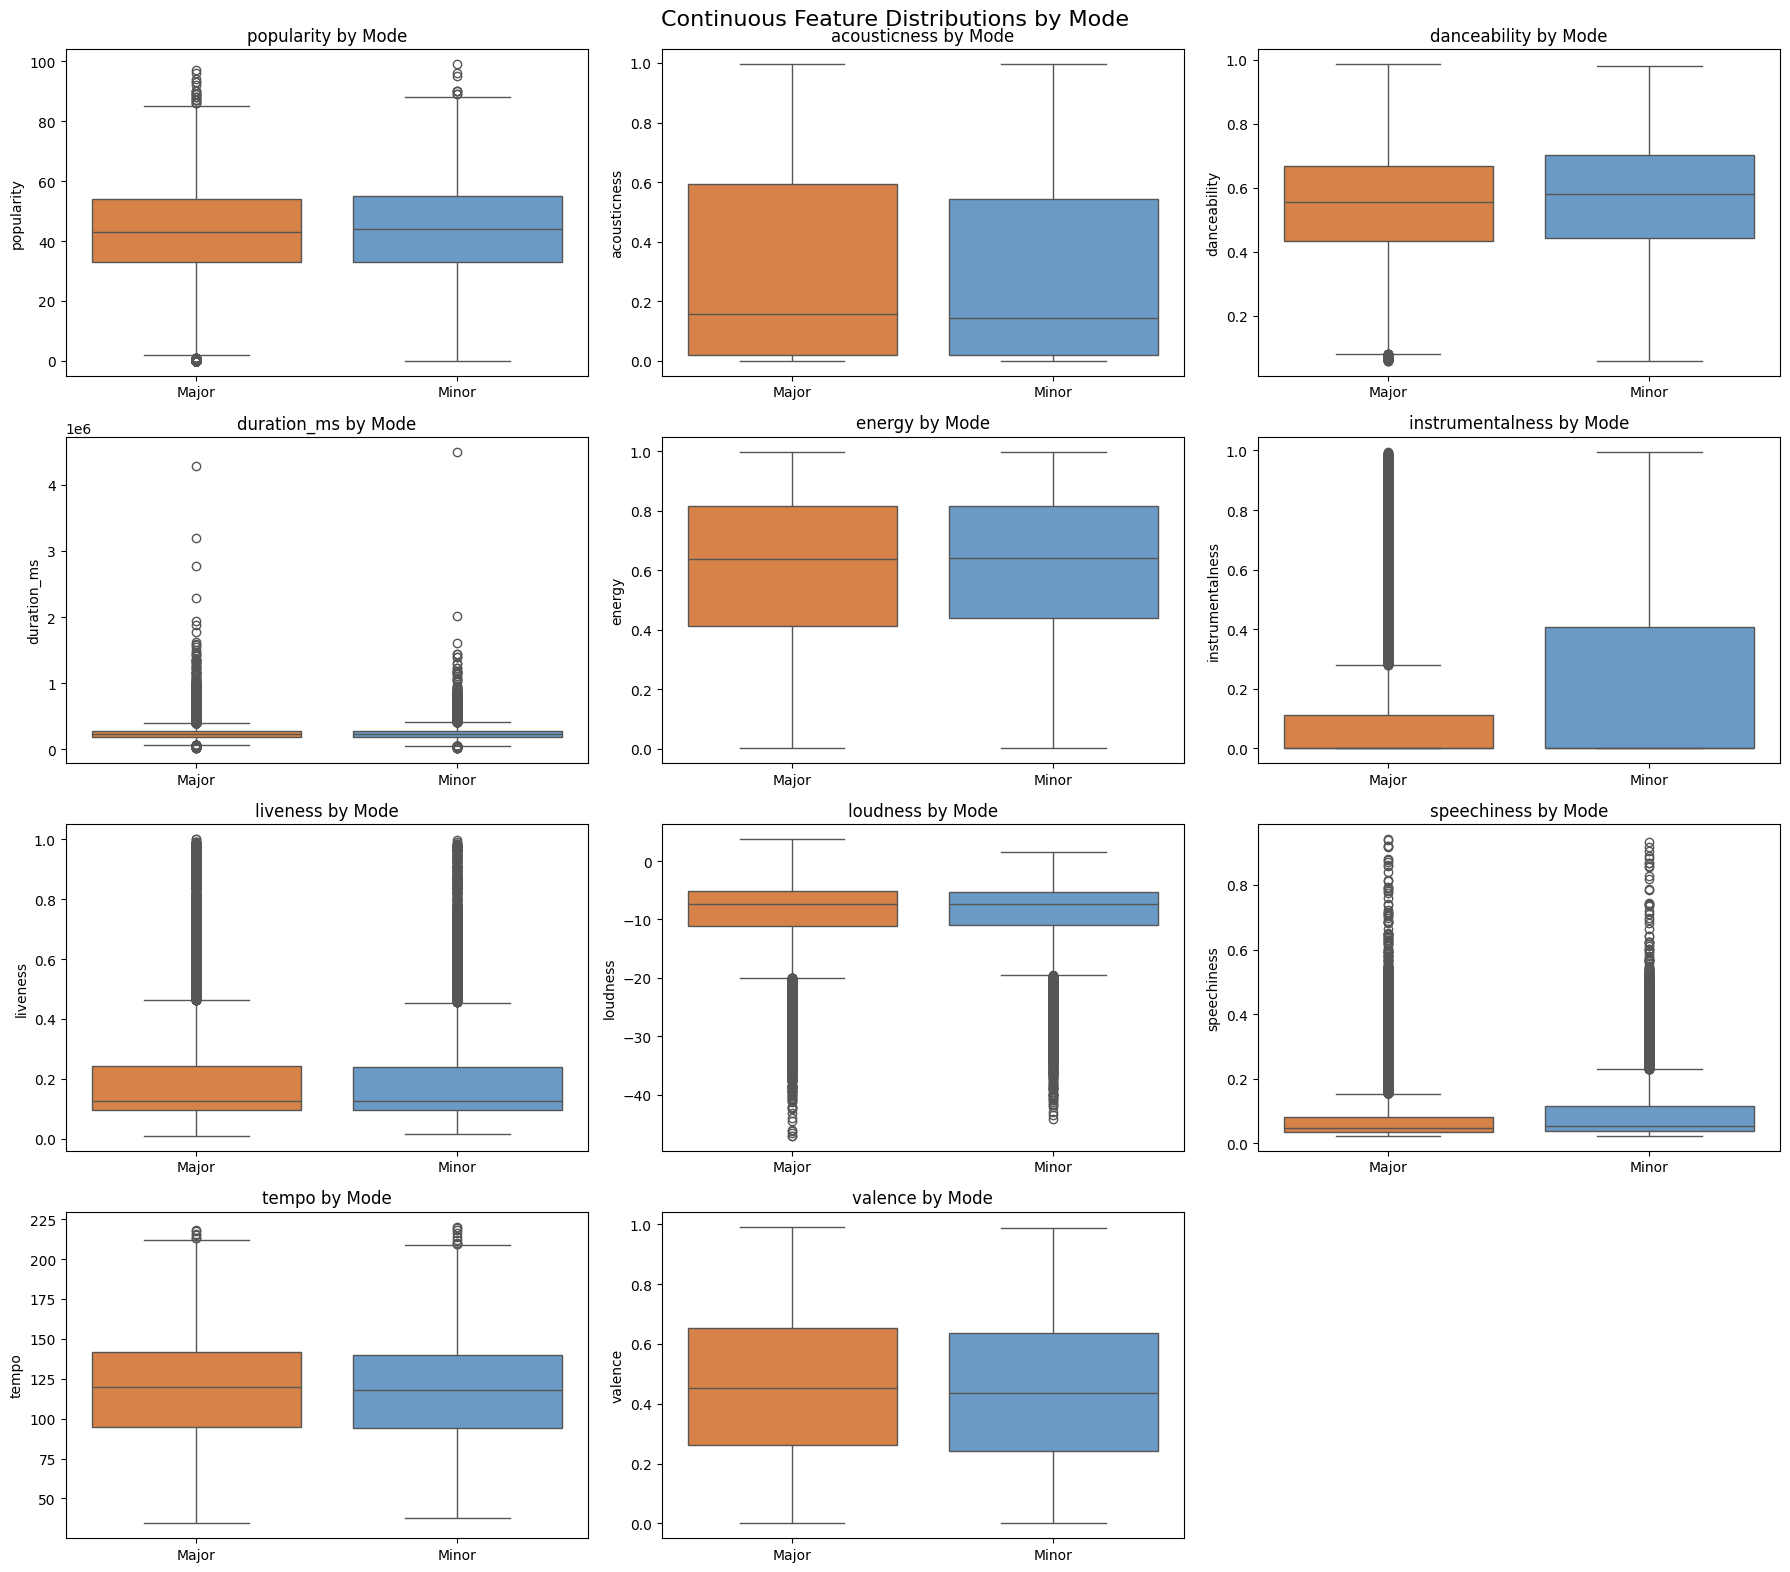

In [44]:
continuous_features = [
    "popularity", "acousticness", "danceability", "duration_ms",
    "energy", "instrumentalness", "liveness", "loudness",
    "speechiness", "tempo", "valence"
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.boxplot(
        data=df, x="mode", y=feature, ax=axes[i],
        palette=["#ED7D31", "#5B9BD5"], hue="mode", legend=False
    )
    axes[i].set_title(f"{feature} by Mode")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Major", "Minor"])
    axes[i].set_xlabel("")

fig.delaxes(axes[11])
plt.suptitle("Continuous Feature Distributions by Mode", fontsize=16)
plt.tight_layout()
plt.show()

#### Major/Minor counts per genre

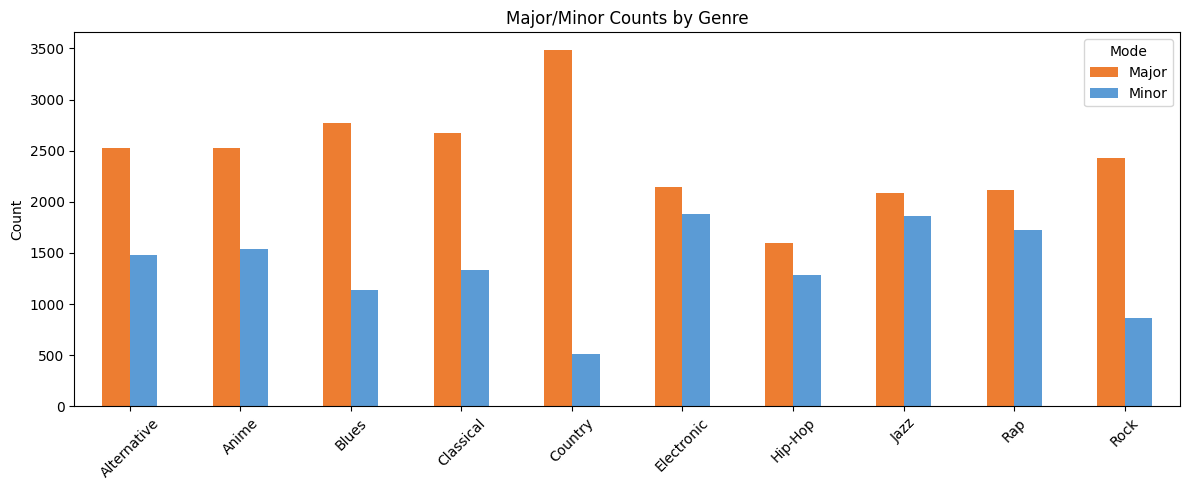

In [45]:
genre_mode = df.groupby(["music_genre", "mode"]).size().unstack(fill_value=0)
genre_mode.columns = ["Major", "Minor"]
genre_mode_pct = genre_mode.div(genre_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
genre_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Counts by Genre")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode", loc="upper right")
plt.tight_layout()
plt.show()

#### Major/Minor counts per key

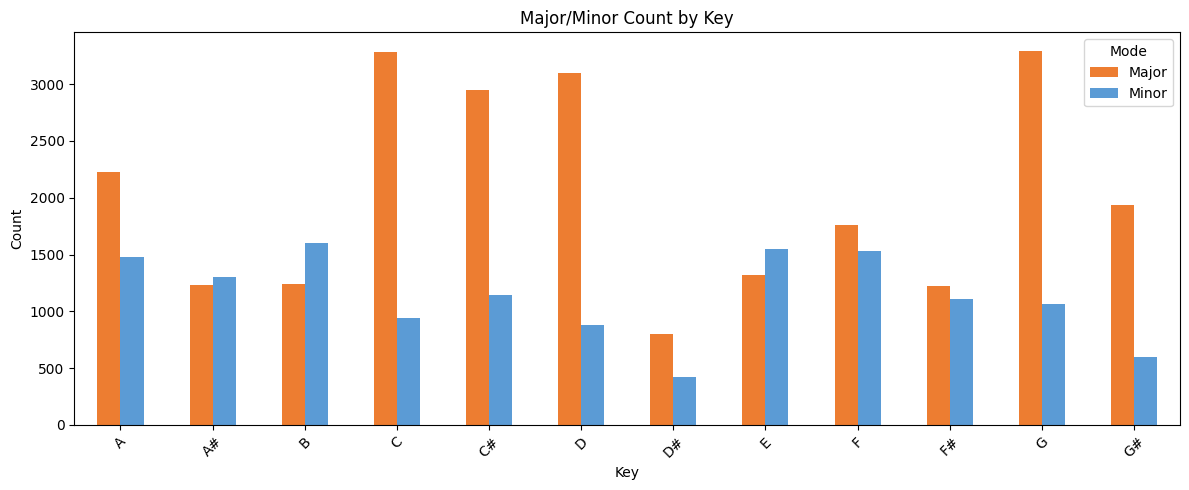

In [46]:
# Recover key names from cyclical encoding
# key_int = round(arctan2(sin, cos) * 12 / 2π) % 12 reverses the sin/cos transform
key_names = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']
key_int = np.round(np.arctan2(df["key_sin"], df["key_cos"]) * 12 / (2 * np.pi)).astype(int) % 12
df_vis = df.copy()
df_vis["key_name"] = key_int.map(dict(enumerate(key_names)))

key_mode = df_vis.groupby(["key_name", "mode"]).size().unstack(fill_value=0)
key_mode.columns = ["Major", "Minor"]
key_mode = key_mode.reindex(key_names)  # order keys musically (A through G#)
key_mode_pct = key_mode.div(key_mode.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))

key_mode.plot(kind="bar", ax=ax, color=["#ED7D31", "#5B9BD5"])
ax.set_title("Major/Minor Count by Key")
ax.set_xlabel("Key")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mode")

plt.tight_layout()
plt.show()

#### Correlation heatmap of all numeric features after encoding

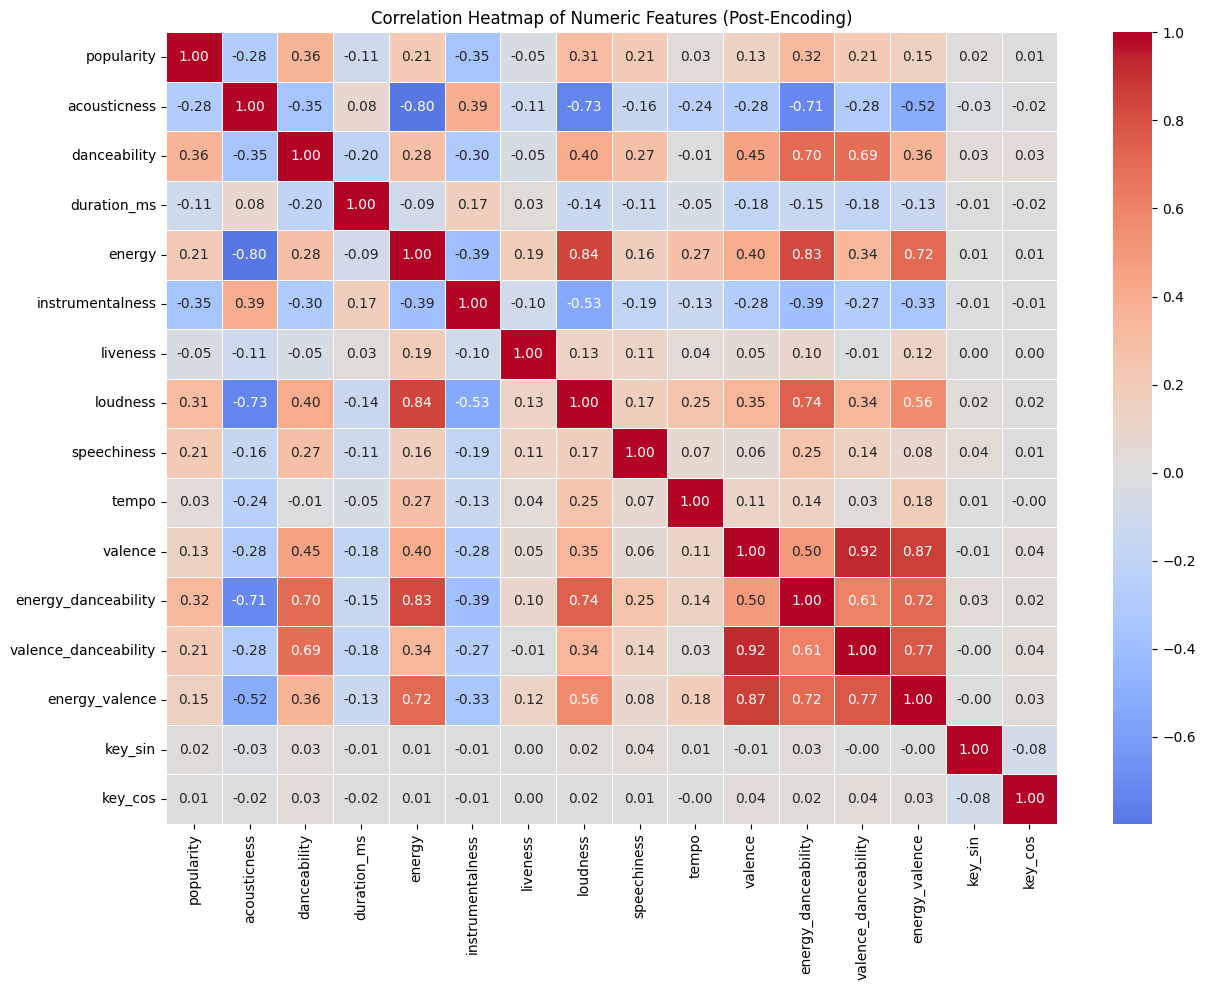

In [47]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["mode"]).columns

plt.figure(figsize=(13, 10))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", center=0, linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features (Post-Encoding)")
plt.tight_layout()
plt.show()

## Data Stratification
#### Stratify with 70% train and 30% test to maintain class balance

In [48]:
X = df.drop(columns=["mode"])
y = df["mode"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## Feature Selection
#### Compute mutual information against `mode`, it measures how much knowing a feature reduces uncertainty about `mode`. 

                Feature  MI Score
                    key  0.035735
    music_genre_Country  0.016273
            speechiness  0.012050
           danceability  0.010630
                 energy  0.007707
    energy_danceability  0.004971
            duration_ms  0.004493
                  tempo  0.004464
 music_genre_Electronic  0.003336
       music_genre_Jazz  0.003262
               loudness  0.002987
               liveness  0.002573
       instrumentalness  0.002298
       music_genre_Rock  0.002005
        music_genre_Rap  0.001833
         energy_valence  0.001637
    music_genre_Hip-Hop  0.001232
      music_genre_Blues  0.001169
           acousticness  0.000656
  music_genre_Classical  0.000106
      music_genre_Anime  0.000066
music_genre_Alternative  0.000025
             popularity  0.000000
                valence  0.000000
   valence_danceability  0.000000


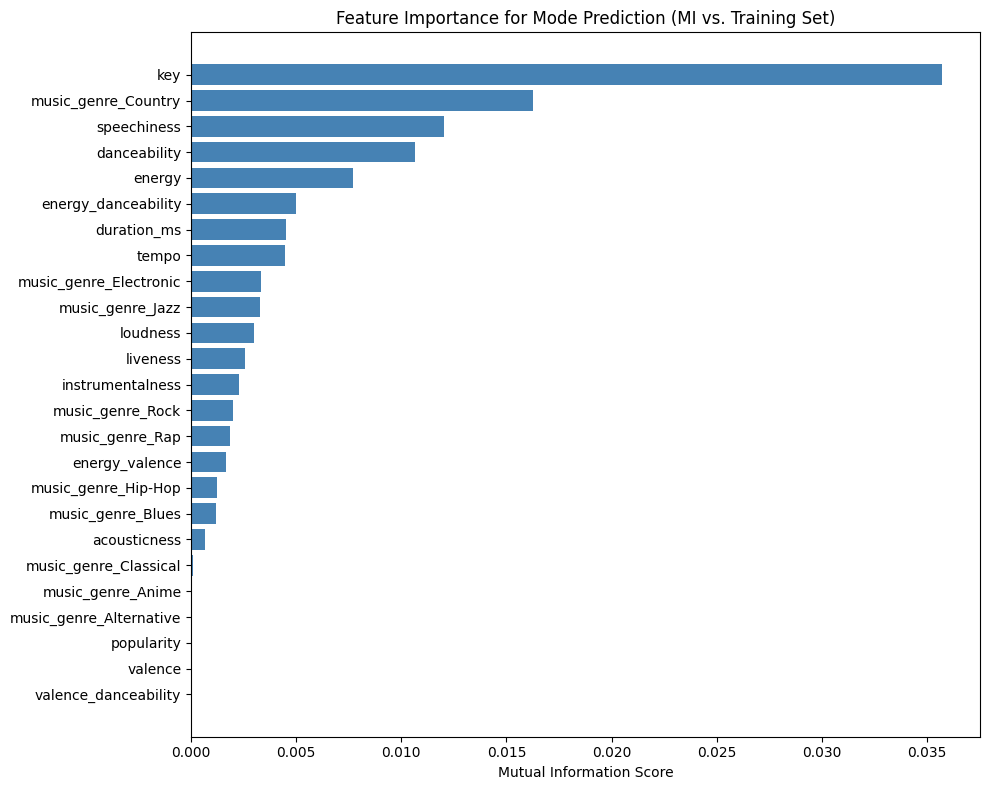

Selected features: ['danceability', 'duration_ms', 'energy', 'speechiness', 'tempo', 'energy_danceability', 'music_genre_Country', 'music_genre_Electronic', 'music_genre_Jazz', 'key_sin', 'key_cos']


In [49]:
# One-hot encode music_genre on train and test separately, then align columns
X_train_enc = pd.get_dummies(X_train, columns=["music_genre"])
X_test_enc = pd.get_dummies(X_test, columns=["music_genre"])

# For MI, key_sin and key_cos are recombined into a single discrete key integer,
# since together they encode one circular variable — computing MI on each separately
# gives two partial scores rather than one accurate measure of key's predictive value.
key_int_train = (
    np.round(np.arctan2(X_train_enc["key_sin"], X_train_enc["key_cos"]) * 12 / (2 * np.pi))
    .astype(int) % 12
)
X_mi = X_train_enc.drop(columns=["key_sin", "key_cos"]).copy()
X_mi["key"] = key_int_train

# Mark discrete features: one-hot genre columns and the recovered key integer
discrete_mask = [c.startswith("music_genre_") or c == "key" for c in X_mi.columns]

mi_scores = mutual_info_classif(X_mi, y_train, discrete_features=discrete_mask, random_state=42)
mi_df = pd.DataFrame({"Feature": X_mi.columns, "MI Score": mi_scores})
mi_df = mi_df.sort_values("MI Score", ascending=False).reset_index(drop=True)

print(mi_df.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(mi_df["Feature"][::-1], mi_df["MI Score"][::-1], color="steelblue")
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance for Mode Prediction (MI vs. Training Set)")
plt.tight_layout()
plt.show()

# SelectKBest uses the same discrete_mask to stay consistent with mi_df above
number_of_features = 10
selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42),
    k=number_of_features
)
selector.fit(X_mi, y_train)

# Get selected feature names, map 'key' back to key_sin/key_cos for model training
selected_features = X_mi.columns[selector.get_support()].tolist()
selected_cols = []
for f in selected_features:
    if f == "key":
        selected_cols += ["key_sin", "key_cos"]
    else:
        selected_cols.append(f)

print("Selected features:", selected_cols)

## Feature Scaling

#### The selected models (SVM, Logistic Regression, Neural Network) are all sensitive to feature scale, so `StandardScaler` is applied.

- Fit only on `X_train`, then transform `X_test` — prevents test statistics from leaking into training.
- `key_sin`/`key_cos` are already in [−1, 1] and are not scaled.
- One-hot encoded `music_genre` columns are 0 and 1, so not scaled.

In [50]:
# Align ensures test has the same columns as train
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

no_scale_cols = [c for c in X_train_enc.columns
                 if c.startswith("music_genre_") or c in ["key_sin", "key_cos"]]
scale_cols = [c for c in X_train_enc.columns if c not in no_scale_cols]

# Fit scaler on X_train only, then transform both sets
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test_enc[scale_cols])
X_train_selected = X_train_scaled[selected_cols]
X_test_selected = X_test_scaled[selected_cols]

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected:  {X_test_selected.shape}")
X_train_scaled.head()

X_train_scaled: (26576, 26)
X_test_scaled:  (11391, 26)
X_train_selected: (26576, 11)
X_test_selected:  (11391, 11)


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,...,music_genre_Alternative,music_genre_Anime,music_genre_Blues,music_genre_Classical,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock
31990,-0.933378,1.743291,-2.087732,-0.431781,-2.066731,1.989044,-0.471691,-2.527857,-0.462824,-1.446871,...,False,False,False,True,False,False,False,False,False,False
33406,-0.348114,1.589672,-1.252707,1.239460,-1.930950,1.144021,-0.616865,-1.940364,-0.446797,0.592388,...,False,False,False,True,False,False,False,False,False,False
28068,1.147562,-0.430558,-0.092639,0.747938,-0.411623,-0.573135,-0.688837,0.010992,-0.615075,-0.845308,...,False,False,False,False,False,False,False,False,False,True
31249,0.107092,1.946184,1.241159,-0.571437,-0.997271,-0.573185,1.613654,-0.156386,1.090738,-0.345436,...,False,False,False,True,False,False,False,False,False,False
584,-1.453613,1.123019,-0.115056,0.348440,0.200137,1.856255,-0.670383,-0.078987,-0.509901,0.783176,...,False,False,False,False,False,True,False,False,False,False


## Data Modeling without Feature Selection

Model Comparison Results:
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5880  0.5947 0.5695
                SVM    0.5564     0.5882  0.5920 0.5556


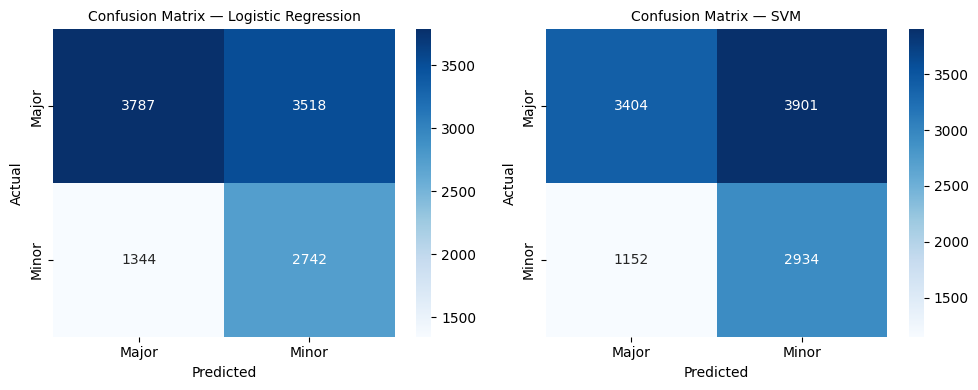

In [51]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    },
    "SVM": {
        "model": SVC(kernel="linear", random_state=42, class_weight="balanced"),
        "X_train": X_train_scaled,
        "X_test": X_test_scaled
    }
}

results = []
conf_matrices = {}
for name, info in models.items():
    model = info["model"]
    X_tr = info["X_train"]
    X_te = info["X_test"]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices[name] = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, matrix) in zip(axes, conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Data Modeling with Feature Selection
#### See if feature selection helps to improve the models' performace.

Model Comparison Results (Top 10 MI Features):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5585     0.5672  0.5727 0.5530
                SVM    0.6090     0.5719  0.5705 0.5711


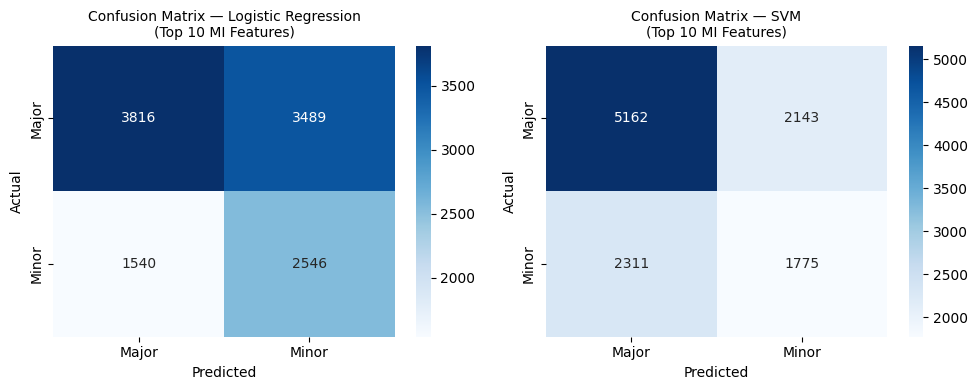

In [52]:
models_sel = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    },
    "SVM": {
        "model": SVC(kernel="linear", random_state=42, class_weight="balanced"),
        "X_train": X_train_selected,
        "X_test": X_test_selected
    }
}

results_sel = []
conf_matrices_sel = {}
for name, info in models_sel.items():
    model = info["model"]
    X_tr = info["X_train"]
    X_te = info["X_test"]

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    conf_matrices_sel[name] = confusion_matrix(y_test, y_pred)

    results_sel.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4)
    })

results_sel_df = pd.DataFrame(results_sel)
print("Model Comparison Results (Top 10 MI Features):")
print(results_sel_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, matrix) in zip(axes, conf_matrices_sel.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name}\n(Top 10 MI Features)", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Neural Network without Feature Selection

In [53]:
mlp = MLPClassifier(max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average="macro", zero_division=0)
rec_mlp  = recall_score(y_test, y_pred_mlp, average="macro", zero_division=0)
f1_mlp   = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)

mlp_result = pd.DataFrame([{
    "Model": "MLP",
    "Accuracy": round(acc_mlp, 4),
    "Precision": round(prec_mlp, 4),
    "Recall": round(rec_mlp, 4),
    "F1": round(f1_mlp, 4)
}])

results_df = pd.concat([results_df, mlp_result], ignore_index=True)
print("Model Comparison Results (Including MLP):")
print(results_df.to_string(index=False))

Model Comparison Results (Including MLP):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5880  0.5947 0.5695
                SVM    0.5564     0.5882  0.5920 0.5556
                MLP    0.6794     0.6450  0.6215 0.6251


## Neural Network with Feature Selection

In [54]:
mlp = MLPClassifier(max_iter=500, random_state=42)
mlp.fit(X_train_selected, y_train)
y_pred_mlp = mlp.predict(X_test_selected)

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average="macro", zero_division=0)
rec_mlp  = recall_score(y_test, y_pred_mlp, average="macro", zero_division=0)
f1_mlp   = f1_score(y_test, y_pred_mlp, average="macro", zero_division=0)

mlp_selected_result = pd.DataFrame([{
    "Model": "MLP",
    "Accuracy": round(acc_mlp, 4),
    "Precision": round(prec_mlp, 4),
    "Recall": round(rec_mlp, 4),
    "F1": round(f1_mlp, 4)
}])

# Remove previous MLP result and add the new one for selected features
results_df = results_df[results_df["Model"] != "MLP"]
results_df = pd.concat([results_df, mlp_selected_result], ignore_index=True)
print("Model Comparison Results (Including MLP):")
print(results_df.to_string(index=False))

Model Comparison Results (Including MLP):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5732     0.5880  0.5947 0.5695
                SVM    0.5564     0.5882  0.5920 0.5556
                MLP    0.6934     0.6632  0.6359 0.6407


## Hyperparameter Tuning
#### Select parameters that are most influencial to the models perfromance against the research question.

In [55]:
# Stratified 5-fold CV preserves the 64/36 Major/Minor ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        # C controls regularisation strength: smaller values = stronger regularisation
        {"C": [0.01, 0.1, 1, 10]},
    ),
    "SVM": (
        SVC(class_weight="balanced", random_state=42),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    ),
    "MLP": (
        MLPClassifier(max_iter=2000, random_state=42),
        {"activation": ["relu", "tanh"],
         "hidden_layer_sizes": [(32,), (64, 32), (128, 64, 32)],
         "alpha": [0.0001, 0.001, 0.01]},
    ),
}

best_models = {}
tuning_results = []

for name, (estimator, grid) in search_specs.items():
    print(f"--- Tuning {name} ---")
    search = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=cv,
        scoring="f1_macro",   # macro F1 weighs Major and Minor equally despite imbalance
        n_jobs=-1,             # parallelise across CPU cores
        refit=True,           # auto-refit best config on full training set after CV
    )
    search.fit(X_train_selected, y_train)

    best_models[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Best Params": str(search.best_params_),
        "Best CV F1": round(search.best_score_, 4),
    })
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV F1:  {search.best_score_:.4f}\n")

tuning_df = pd.DataFrame(tuning_results)
print("Cross-Validation Tuning Summary:")
print(tuning_df.to_string(index=False))

--- Tuning Logistic Regression ---
  Best params: {'C': 0.01}
  Best CV F1:  0.5621

--- Tuning SVM ---
  Best params: {'C': 1, 'kernel': 'rbf'}
  Best CV F1:  0.6403

--- Tuning MLP ---
  Best params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (32,)}
  Best CV F1:  0.6393

Cross-Validation Tuning Summary:
              Model                                                          Best Params  Best CV F1
Logistic Regression                                                          {'C': 0.01}      0.5621
                SVM                                            {'C': 1, 'kernel': 'rbf'}      0.6403
                MLP {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (32,)}      0.6393


## Final Evaluation on Held-out Test Set
#### Each tuned model (`best_models`) is evaluated on `X_test_selected` — touched only here, after every tuning decision was made on the training set. These numbers are the unbiased estimate of generalisation performance.

Final Test Set Results (Tuned Models):
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.5618     0.5674  0.5731 0.5552
                SVM    0.6628     0.6421  0.6496 0.6439
                MLP    0.7006     0.6788  0.6290 0.6323


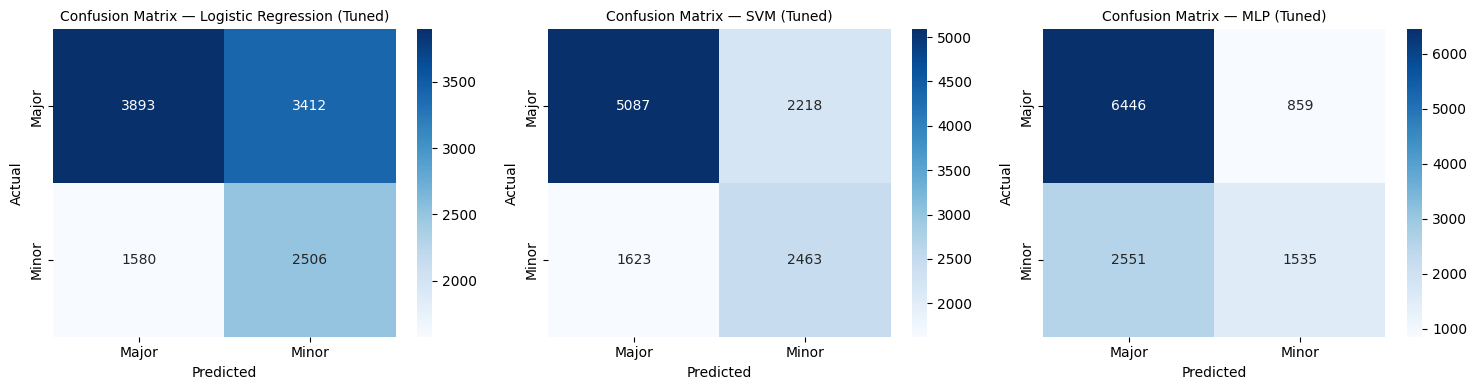

In [56]:
final_results = []
final_conf_matrices = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_selected)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

    final_conf_matrices[name] = confusion_matrix(y_test, y_pred)
    final_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

final_df = pd.DataFrame(final_results)
print("Final Test Set Results (Tuned Models):")
print(final_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, matrix) in zip(axes, final_conf_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Major", "Minor"], yticklabels=["Major", "Minor"])
    ax.set_title(f"Confusion Matrix — {name} (Tuned)", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Untuned vs Tuned (Selected Features, Test Set):
             Setting               Model  Accuracy  Precision  Recall     F1
Tuned (GridSearchCV) Logistic Regression    0.5618     0.5674  0.5731 0.5552
  Untuned (defaults) Logistic Regression    0.5585     0.5672  0.5727 0.5530
Tuned (GridSearchCV)                 MLP    0.7006     0.6788  0.6290 0.6323
  Untuned (defaults)                 MLP    0.6934     0.6632  0.6359 0.6407
Tuned (GridSearchCV)                 SVM    0.6628     0.6421  0.6496 0.6439
  Untuned (defaults)                 SVM    0.6090     0.5719  0.5705 0.5711

F1 Improvement:
Setting              Untuned (defaults)  Tuned (GridSearchCV)    Δ F1
Model                                                                
Logistic Regression              0.5530                0.5552  0.0022
MLP                              0.6407                0.6323 -0.0084
SVM                              0.5711                0.6439  0.0728


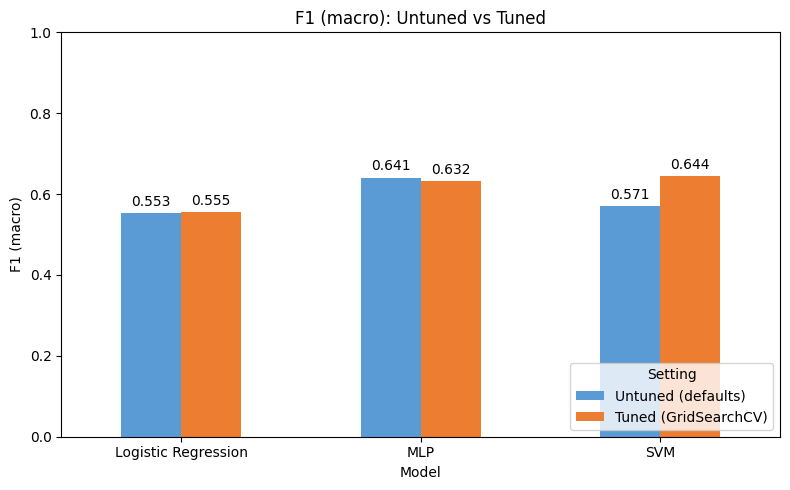

In [57]:
# Untuned baseline (selected features) for all 3 models:
#   - results_sel_df contains LR + SVM
#   - results_df's MLP entry was last set in cell f81ace70 (selected features)
untuned = pd.concat(
    [results_sel_df, results_df[results_df["Model"] == "MLP"]],
    ignore_index=True
)
untuned["Setting"] = "Untuned (defaults)"

tuned = final_df.copy()
tuned["Setting"] = "Tuned (GridSearchCV)"

# Side-by-side table
combined = pd.concat([untuned, tuned], ignore_index=True)
combined = combined[["Setting", "Model", "Accuracy", "Precision", "Recall", "F1"]]
combined = combined.sort_values(["Model", "Setting"]).reset_index(drop=True)
print("Untuned vs Tuned (Selected Features, Test Set):")
print(combined.to_string(index=False))

# F1 bar chart for visual comparison
pivot = combined.pivot(index="Model", columns="Setting", values="F1")
pivot = pivot[["Untuned (defaults)", "Tuned (GridSearchCV)"]]
pivot["Δ F1"] = pivot["Tuned (GridSearchCV)"] - pivot["Untuned (defaults)"]
print("\nF1 Improvement:")
print(pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
pivot[["Untuned (defaults)", "Tuned (GridSearchCV)"]].plot(
    kind="bar", ax=ax, color=["#5B9BD5", "#ED7D31"]
)
ax.set_title("F1 (macro): Untuned vs Tuned")
ax.set_ylabel("F1 (macro)")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Setting", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()